# Task 5: de-anonymizing the 100 assets

The anonymized files keep real trading dates, and each close is the real (dividend-adjusted) close times a per-asset constant. Daily log returns are therefore unchanged, and they identify each stock.

Method:
1. Download the current S&P 500 constituents, plus a few large US-listed ADRs that are not in the index, from Yahoo with FinRL's `YahooDownloader` (vendored in `yahoodownloader.py`), 2016-01-01 to 2026-01-16.
2. Correlate each anonymized asset's daily log returns with every S&P 500 stock.
3. Solve a one-to-one assignment (Hungarian algorithm) that maximizes total correlation.
4. Check each match: the runner-up correlation should be far lower, and anonymized / real price should be a constant.

Result: 99 assets are S&P 500 members. One (Asset_011) is TSM, the Taiwan Semiconductor ADR, which is not in the index. The universe looks like the largest US-listed stocks by market cap, roughly in rank order.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mapping import (ARTIFACTS, load_anonymized, sp500_constituents, download_prices,
                     log_returns, return_correlations, match, price_scale)

## Data

In [2]:
anon = load_anonymized()

# Large US-listed ADRs outside the S&P 500. Without TSM, Asset_011 has no match.
extra = pd.DataFrame([
    ("TSM", "Taiwan Semiconductor (ADR)", "Information Technology", "Semiconductors"),
    ("ASML", "ASML Holding (ADR)", "Information Technology", "Semiconductor Materials & Equipment"),
    ("NVO", "Novo Nordisk (ADR)", "Health Care", "Pharmaceuticals"),
    ("SAP", "SAP (ADR)", "Information Technology", "Application Software"),
    ("BABA", "Alibaba (ADR)", "Consumer Discretionary", "Broadline Retail"),
    ("TM", "Toyota Motor (ADR)", "Consumer Discretionary", "Automobile Manufacturers"),
], columns=["ticker", "name", "sector", "sub_industry"])
START, END = "2016-01-01", "2026-01-17"  # END is exclusive
UNIVERSE_FILE = ARTIFACTS / "universe.csv"
PRICES_FILE = ARTIFACTS / "yahoo_prices.csv.gz"

# Download only once. Delete these two files to refetch.
if UNIVERSE_FILE.exists() and PRICES_FILE.exists():
    universe = pd.read_csv(UNIVERSE_FILE)
    real = pd.read_csv(PRICES_FILE, parse_dates=["date"])
    print("Loaded cached universe and prices from", ARTIFACTS)
else:
    universe = pd.concat([sp500_constituents().assign(in_sp500=True), extra.assign(in_sp500=False)],
                         ignore_index=True)
    real = download_prices(universe["ticker"], START, END)
    ARTIFACTS.mkdir(parents=True, exist_ok=True)
    universe.to_csv(UNIVERSE_FILE, index=False)
    real.to_csv(PRICES_FILE, index=False)
    print("Downloaded and saved universe and prices to", ARTIFACTS)

print("anonymized:", anon["tic"].nunique(), "assets,", anon["date"].min().date(), "to", anon["date"].max().date())
print("candidates:", real["tic"].nunique(), "of", len(universe), "tickers downloaded")

Loaded cached universe and prices from C:\Users\Himanshu Srivastava\OneDrive\Desktop\Projects\precog_test\task5\artifacts
anonymized: 100 assets, 2016-01-25 to 2026-01-16
candidates: 507 of 509 tickers downloaded


## Match on daily returns

In [3]:
corr = return_correlations(log_returns(anon), log_returns(real))
mapping = match(corr)
mapping = (mapping
           .merge(price_scale(anon, real, mapping), on="asset")
           .merge(universe, on="ticker", how="left")
           .sort_values("asset")
           .reset_index(drop=True))
mapping.to_csv(ARTIFACTS / "asset_mapping.csv", index=False)
mapping.round(4)

,asset,ticker,corr,runner_up_corr,runner_up,scale,scale_cv,shared_days,name,sector,sub_industry,in_sp500
0,Asset_001,AAPL,1.0,0.6755,MSFT,1.2782,0.0,2511,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals",True
1,Asset_002,MSFT,1.0,0.7040,GOOGL,1.3952,0.0,2511,Microsoft,Information Technology,Systems Software,True
2,Asset_003,GOOG,1.0,0.9952,GOOGL,1.0306,0.0,2511,Alphabet Inc. (Class C),Communication Services,Interactive Media & Services,True
3,Asset_004,AMZN,1.0,0.6652,MSFT,1.1442,0.0,2511,Amazon,Consumer Discretionary,Broadline Retail,True
4,Asset_005,NVDA,1.0,0.6750,MPWR,1.3127,0.0,2511,Nvidia,Information Technology,Semiconductors,True
...,...,...,...,...,...,...,...,...,...,...,...,...
95,Asset_096,ITW,1.0,0.7578,PH,0.8924,0.0,2511,Illinois Tool Works,Industrials,Industrial Machinery & Supplies & Components,True
96,Asset_097,MU,1.0,0.7323,LRCX,0.9777,0.0,2511,Micron Technology,Information Technology,Semiconductors,True
97,Asset_098,CL,1.0,0.7223,PG,1.2546,0.0,2511,Colgate-Palmolive,Consumer Staples,Household Products,True
98,Asset_099,EQIX,1.0,0.7361,DLR,0.7827,0.0,2511,Equinix,Real Estate,Data Center REITs,True


## How clear are the matches?

Each dot is one asset. A true match sits near a correlation of 1 on the y-axis. The runner-up (x-axis) is the best other stock, which is usually a same-sector peer. `scale_cv` near 0 means anonymized / real price is a constant, so the rescaling is the only change.

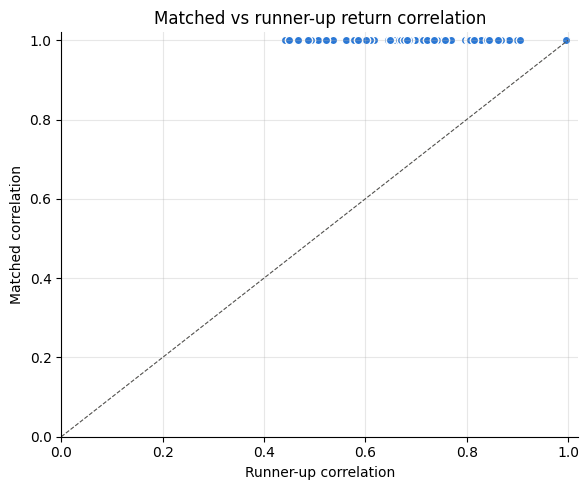

        corr  runner_up_corr  scale_cv
count  100.0        100.0000     100.0
mean     1.0          0.6914       0.0
std      0.0          0.1243       0.0
min      1.0          0.4412       0.0
25%      1.0          0.6049       0.0
50%      1.0          0.6856       0.0
75%      1.0          0.7976       0.0
max      1.0          0.9952       0.0

0 matches need a manual look:


,asset,ticker,corr,runner_up_corr,runner_up,scale,scale_cv,shared_days,name,sector,sub_industry,in_sp500


In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(mapping["runner_up_corr"], mapping["corr"], s=36, color="#2a78d6", edgecolor="white", linewidth=1)
ax.plot([0, 1], [0, 1], color="#52514e", ls="--", lw=0.8)
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
ax.set_xlabel("Runner-up correlation")
ax.set_ylabel("Matched correlation")
ax.set_title("Matched vs runner-up return correlation")
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

print(mapping[["corr", "runner_up_corr", "scale_cv"]].describe().round(4))
weak = mapping[(mapping["corr"] < 0.95) | (mapping["scale_cv"] > 0.01)]
print(f"\n{len(weak)} matches need a manual look:")
weak.round(4)

## Spot check: anonymized close / scale vs Yahoo adjusted close

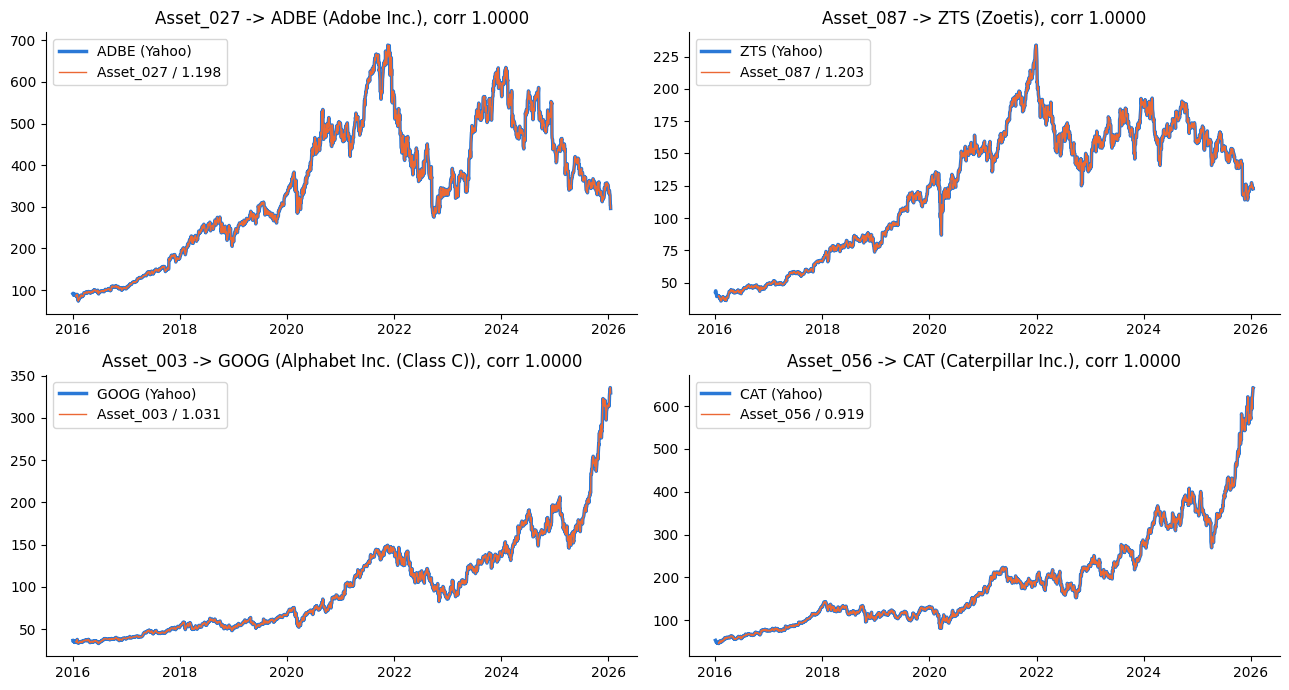

In [5]:
real_wide = real.pivot(index="date", columns="tic", values="close")
anon_wide = anon.pivot(index="date", columns="tic", values="close")

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, row in zip(axes.flat, mapping.sample(4, random_state=0).itertuples()):
    ax.plot(real_wide.index, real_wide[row.ticker], color="#2a78d6", lw=2.5, label=f"{row.ticker} (Yahoo)")
    ax.plot(anon_wide.index, anon_wide[row.asset] / row.scale, color="#eb6834", lw=1, label=f"{row.asset} / {row.scale:.3f}")
    ax.set_title(f"{row.asset} -> {row.ticker} ({row.name}), corr {row.corr:.4f}")
    ax.legend(loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

## What the 100 assets are

In [6]:
mapping["sector"].value_counts()

sector
Health Care               20
Information Technology    18
Financials                17
Industrials               12
Consumer Staples           9
Consumer Discretionary     8
Communication Services     7
Energy                     4
Utilities                  2
Real Estate                2
Materials                  1
Name: count, dtype: int64

In [14]:
cols=["asset", "ticker", "name"]
pd.set_option('display.max_rows', None)
print(mapping[cols])

        asset ticker                         name
0   Asset_001   AAPL                   Apple Inc.
1   Asset_002   MSFT                    Microsoft
2   Asset_003   GOOG      Alphabet Inc. (Class C)
3   Asset_004   AMZN                       Amazon
4   Asset_005   NVDA                       Nvidia
5   Asset_006   META               Meta Platforms
6   Asset_007   TSLA                  Tesla, Inc.
7   Asset_008  BRK-B           Berkshire Hathaway
8   Asset_009    LLY                  Lilly (Eli)
9   Asset_010      V                    Visa Inc.
10  Asset_011    TSM   Taiwan Semiconductor (ADR)
11  Asset_012    UNH           UnitedHealth Group
12  Asset_013    XOM                   ExxonMobil
13  Asset_014    JPM               JPMorgan Chase
14  Asset_015    WMT                      Walmart
15  Asset_016     MA                   Mastercard
16  Asset_017     PG             Procter & Gamble
17  Asset_018    JNJ            Johnson & Johnson
18  Asset_019   AVGO                     Broadcom
